# Классификация SI относительно медианы

В этом ноутбуке решается задача бинарной классификации для показателя `SI`.

Цель -> определить, превышает ли значение `SI` медианное значение выборки.

Класс `0` означает, что `SI` меньше либо равно медиане.
Класс `1` означает, что `SI` больше медианы.

# Импорты

In [37]:
# Библиотеки для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt

# Метрики классификации
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Разделение данных
from sklearn.model_selection import train_test_split

# Загрузка общих конфигов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_SI,
    TEST_SIZE,
)
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import (
    load_coursework_dataset,
)
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import (
    run_classification_experiment,
)
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import (
    get_classification_models,
)
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_classification_results,
)
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    build_si_above_median_target,
    preprocess_features,
)

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

## Загрузка данных

Загрузим исходный датасет с молекулярными дескрипторами и целевыми переменными.

In [38]:
df = load_coursework_dataset()

df.shape

(1001, 214)

In [39]:
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.

## Подготовка признаков и целевой переменной

Сформируем матрицу признаков `X` и бинарную целевую переменную `y`.

Целевая переменная строится по правилу:

- `0` -> `SI <= median`
- `1` -> `SI > median`

Из признаков исключаются служебные столбцы и все целевые переменные: `IC50, mM`, `CC50, mM`, `SI`.

Это необходимо, чтобы не допустить утечки данных.

In [40]:
X = build_features(df)

y = build_si_above_median_target(df)

si_median = df[TARGET_SI].median()

print(f"Размер исходной матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print(f"Медианное значение {TARGET_SI}: {si_median:.4f}")

Размер исходной матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Медианное значение SI: 3.8462


## Распределение классов

Проверим, насколько сбалансированы классы.

Так как целевая переменная построена относительно медианы, ожидается достаточно равномерное распределение классов.

In [41]:
class_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["share"] = class_distribution["count"] / class_distribution["count"].sum()

class_distribution

,class,count,share
0,0,501,0.5005
1,1,500,0.4995


## Предобработка признаков

По итогам EDA выполним очистку признакового пространства.

Удалим:
- константные признаки
- почти константные признаки
- сильно коррелирующие признаки

Целевую переменную не изменяем.

In [42]:
X_clean, preprocessing_report = preprocess_features(X)

print(f"Размер матрицы признаков до обработки: {X.shape}")
print(f"Размер матрицы признаков после обработки: {X_clean.shape}")
print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [43]:
preprocessing_summary = pd.DataFrame(
    {
        "step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features",
            "remaining_features",
        ],
        "count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,step,count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features,76
4,remaining_features,134


## Подготовка моделей классификации

Для сравнения используем несколько моделей бинарной классификации:

- DummyClassifier
- Logistic Regression
- KNN
- SVC
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

`DummyClassifier` используется как базовая модель.
Он необходим для проверки, действительно ли остальные модели находят полезные закономерности в данных.

In [44]:
classification_models = get_classification_models()

classification_models.keys()

dict_keys(['dummy_most_frequent', 'logistic_regression', 'knn', 'svc_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

## Обучение моделей

Обучим модели на обработанных признаках.

Для оценки качества используем:

- кросс-валидацию по `F1`
- качество на тестовой выборке
- accuracy
- balanced accuracy
- precision
- recall
- F1
- ROC-AUC

Основной метрикой для выбора лучшей модели будет `F1`.

In [45]:
si_classification_results, si_fitted_models = run_classification_experiment(
    X=X_clean,
    y=y,
    models=classification_models,
)

si_classification_results["feature_set"] = "preprocessed_features"
si_classification_results["target"] = "si_above_median"

si_classification_results

,model,cv_f1_mean,cv_f1_std,train_rows,test_rows,fit_time_sec,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,feature_set,target
0,knn,0.659679,0.017914,800,201,0.038063,0.676617,0.676980,0.652174,0.75,0.697674,0.722525,preprocessed_features,si_above_median
1,hist_gradient_boosting,0.655009,0.023441,800,201,1.838471,0.646766,0.646733,0.646465,0.64,0.643216,0.661733,preprocessed_features,si_above_median
2,catboost,0.651686,0.032456,800,201,4.077442,0.651741,0.651584,0.659574,0.62,0.639175,0.685792,preprocessed_features,si_above_median
3,svc_rbf,0.650839,0.028286,800,201,0.251662,0.611940,0.612030,0.605769,0.63,0.617647,0.649703,preprocessed_features,si_above_median
4,random_forest,0.647618,0.024630,800,201,0.657775,0.641791,0.641436,0.662791,0.57,0.612903,0.688267,preprocessed_features,si_above_median
5,extra_trees,0.663063,0.032473,800,201,0.484998,0.626866,0.626683,0.634409,0.59,0.611399,0.681436,preprocessed_features,si_above_median
6,logistic_regression,0.655876,0.036939,800,201,0.054957,0.601990,0.601980,0.600000,0.60,0.600000,0.638168,preprocessed_features,si_above_median
7,dummy_most_frequent,0.000000,0.000000,800,201,0.027128,0.502488,0.500000,0.000000,0.00,0.000000,0.500000,preprocessed_features,si_above_median


In [46]:
si_classification_results.to_csv(
    METRICS_DIR / "classification_si_median_metrics.csv",
    index=False,
)

## График сравнения моделей

Построим график сравнения моделей по метрике `F1`.

Чем выше значение `F1`, тем лучше модель сохраняет баланс между точностью и полнотой.

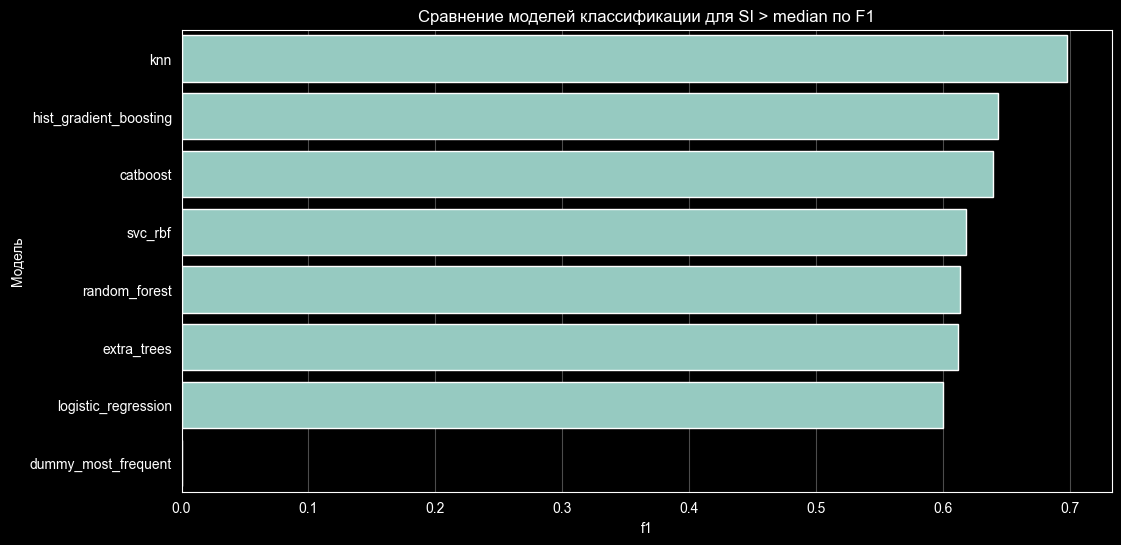

In [47]:
plot_classification_results(
    results_df=si_classification_results,
    metric="f1",
    title="Сравнение моделей классификации для SI > median по F1",
)

## Выбор лучшей модели

Выберем модель с максимальным значением `F1`.

Дополнительно посмотрим:

- набор признаков
- целевую переменную
- accuracy
- balanced accuracy
- precision
- recall
- F1
- ROC-AUC

In [48]:
best_result = si_classification_results.iloc[0]

best_result

model                                  knn
cv_f1_mean                        0.659679
cv_f1_std                         0.017914
train_rows                             800
test_rows                              201
fit_time_sec                      0.038063
accuracy                          0.676617
balanced_accuracy                  0.67698
precision                         0.652174
recall                                0.75
f1                                0.697674
roc_auc                           0.722525
feature_set          preprocessed_features
target                     si_above_median
Name: 0, dtype: object

In [49]:
best_model_name = best_result["model"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_result['feature_set']}")
print(f"Целевая переменная: {best_result['target']}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Balanced accuracy: {best_result['balanced_accuracy']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")
print(f"F1: {best_result['f1']:.4f}")
print(f"ROC-AUC: {best_result['roc_auc']:.4f}")

Лучшая модель: knn
Набор признаков: preprocessed_features
Целевая переменная: si_above_median
Accuracy: 0.6766
Balanced accuracy: 0.6770
Precision: 0.6522
Recall: 0.7500
F1: 0.6977
ROC-AUC: 0.7225


## Предсказания лучшей модели

Получим предсказания лучшей модели на тестовой выборке.

Разделение делаем с `stratify=y`, чтобы сохранить распределение классов в train/test.

In [50]:
best_model = si_fitted_models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "classification_si_median_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
348,1,1
732,0,0
87,0,1
512,0,1
173,1,1


## Отчет классификации

Посмотрим `precision`, `recall` и `F1` отдельно по каждому классу.

In [51]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "SI <= median",
            "SI > median",
        ],
    )
)

              precision    recall  f1-score   support

SI <= median       0.71      0.60      0.65       101
 SI > median       0.65      0.75      0.70       100

    accuracy                           0.68       201
   macro avg       0.68      0.68      0.68       201
weighted avg       0.68      0.68      0.67       201



## Матрица ошибок

Построим матрицу ошибок для лучшей модели.

Она показывает, сколько объектов каждого класса модель классифицировала правильно и сколько перепутала.

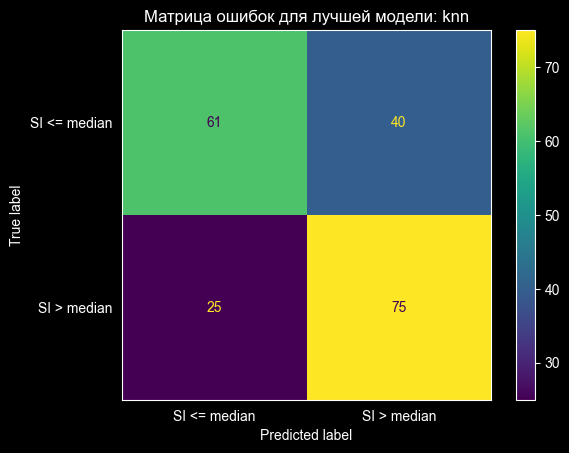

In [52]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "SI <= median",
        "SI > median",
    ],
)

plt.title(f"Матрица ошибок для лучшей модели: {best_model_name}")
plt.grid(False)
plt.show()

## Анализ важности признаков

Если лучшая модель поддерживает `feature_importances_`, можно использовать встроенную важность признаков.

Если лучшая модель не поддерживает встроенную важность признаков, используем permutation importance.

In [53]:
permutation_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": X_clean.columns,
            "importance_mean": permutation_result.importances_mean,
            "importance_std": permutation_result.importances_std,
        }
    )
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance_mean,importance_std
0,PEOE_VSA6,0.019737,0.005253
1,VSA_EState4,0.019086,0.007894
2,EState_VSA8,0.017625,0.006341
3,BCUT2D_MRHI,0.017160,0.005784
4,PEOE_VSA12,0.016572,0.004453
5,fr_NH2,0.015619,0.005817
6,MaxAbsEStateIndex,0.014547,0.003911
7,SMR_VSA7,0.014461,0.009066
8,fr_thiazole,0.014295,0.003965
9,MolLogP,0.014217,0.005389


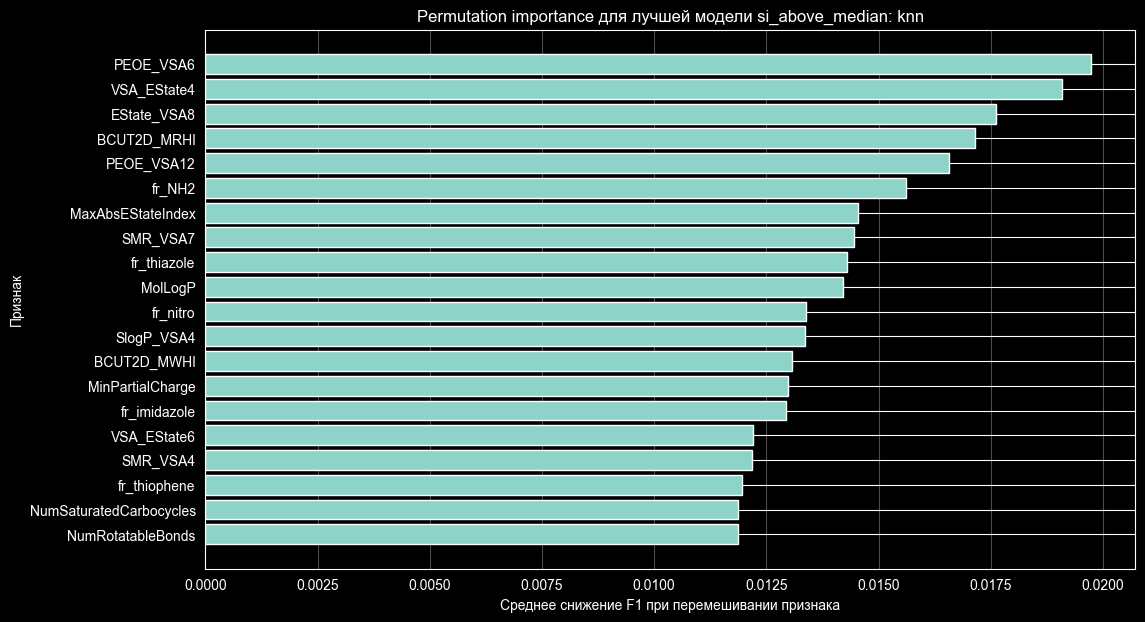

In [54]:
top_importance_df = importance_df.head(20)

plt.figure(figsize=(12, 7))
plt.barh(
    top_importance_df["feature"][::-1],
    top_importance_df["importance_mean"][::-1],
)
plt.title(f"Permutation importance для лучшей модели si_above_median: {best_model_name}")
plt.xlabel("Среднее снижение F1 при перемешивании признака")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Итоговый вывод по задаче классификации SI > median

В данном ноутбуке была решена задача бинарной классификации для показателя `SI`.

Целевая переменная была сформирована по правилу:

- класс `0` —> `SI <= median`;
- класс `1` —> `SI > median`.

Медианное значение `SI` составило `3.8462`.

Так как целевая переменная формировалась относительно медианы, классы получились практически сбалансированными:

- класс `0`: 501 объект, доля `0.5005`;
- класс `1`: 500 объектов, доля `0.4995`.

После предобработки матрица признаков была сокращена с 210 до 134 признаков.

В процессе очистки были удалены:

- 18 константных признаков
- 15 почти константных признаков
- 43 сильно коррелирующих признака
- всего удалено 76 признаков

Для сравнения были обучены несколько моделей бинарной классификации:

- DummyClassifier
- Logistic Regression
- KNN
- SVC
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

Базовая модель `DummyClassifier` показала ожидаемо низкое качество, что подтверждает необходимость использования моделей машинного обучения.

Лучшей моделью по значению F1 стала модель `KNN`.

Итоговые метрики лучшей модели:

- Accuracy: `0.6766`
- Balanced accuracy: `0.6770`
- Precision: `0.6522`
- Recall: `0.7500`
- F1: `0.6977`
- ROC-AUC: `0.7225`

По отчету классификации видно, что модель лучше определяет класс `SI > median`, чем класс `SI <= median`:

- для класса `SI <= median` -> precision `0.71`, recall `0.60`, F1 `0.65`
- для класса `SI > median` -> precision `0.65`, recall `0.75`, F1 `0.70`

Матрица ошибок показывает, что модель чаще относит объекты к классу `SI > median`:

- 61 объект класса `SI <= median` классифицирован верно
- 40 объектов класса `SI <= median` ошибочно отнесены к классу `SI > median`
- 75 объектов класса `SI > median` классифицированы верно
- 25 объектов класса `SI > median` ошибочно отнесены к классу `SI <= median`

Таким образом, модель имеет умеренное качество и заметно превосходит базовый классификатор.
Однако качество ниже, чем в задачах классификации `IC50` и `CC50` относительно медианы.
Это может быть связано с тем, что `SI` является производным показателем, зависящим от соотношения `CC50` и `IC50`,
поэтому его сложнее восстановить только по молекулярным дескрипторам.

Анализ permutation importance показал, что наибольший вклад в качество модели внесли признаки:

- `PEOE_VSA6`
- `VSA_EState4`
- `EState_VSA8`
- `BCUT2D_MRHI`
- `PEOE_VSA12`
- `fr_NH2`
- `MaxAbsEStateIndex`
- `SMR_VSA7`
- `fr_thiazole`
- `MolLogP`

### Итог

Задача классификации `SI > median` решается лучше случайного угадывания, но качество модели остается умеренным.
Для дальнейшего улучшения результата можно дополнительно подобрать гиперпараметры KNN,
проверить масштабирование признаков, попробовать отбор признаков
и сравнить качество с моделями градиентного бустинга после настройки параметров.